In [1]:
pip install librosa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [8]:
BIRD_FOLDER = r"E:\dataset\bird_audio"
NON_BIRD_FOLDER = r"E:\dataset\non_bird"

In [9]:
IMG_SIZE = 128
SR = 22050
DURATION = 3

In [10]:
def audio_to_spec(path):

    try:
        # Load audio
        audio, sr = librosa.load(
            path,
            sr=SR,
            duration=DURATION
        )

        # Skip empty audio
        if len(audio) == 0:
            return None

        # Pad short audio
        target_length = int(SR * DURATION)

        if len(audio) < target_length:
            audio = np.pad(
                audio,
                (0, target_length - len(audio))
            )
        else:
            audio = audio[:target_length]

        # Create Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=128
        )

        # Convert to dB
        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Resize to fixed size
        mel_db = tf.image.resize(
            mel_db[..., np.newaxis],
            (IMG_SIZE, IMG_SIZE)
        )

        mel_db = mel_db.numpy()

        # Normalize safely
        min_val = np.min(mel_db)
        max_val = np.max(mel_db)

        if max_val - min_val <= 1e-6:
            return None

        mel_db = (mel_db - min_val) / (max_val - min_val)

        # Check for NaN values
        if np.isnan(mel_db).any():
            return None

        return mel_db.astype(np.float32)

    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None

In [11]:
file = r"E:\dataset\bird_audio\A-M\ameavo\XC544029.mp3"

spec = audio_to_spec(file)

print(spec.shape)

(128, 128, 1)


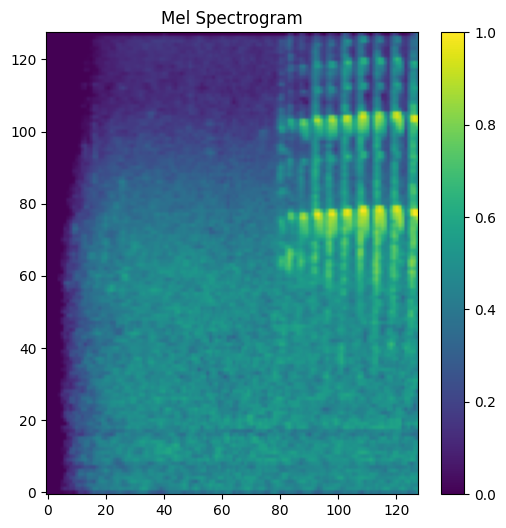

In [12]:
plt.figure(figsize=(6,6))

plt.imshow(
    spec.squeeze(),
    aspect='auto',
    origin='lower'
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

In [13]:
import glob

bird_files = glob.glob(
    BIRD_FOLDER + "/**/*.mp3",
    recursive=True
)

print("Bird Files:", len(bird_files))

Bird Files: 14685


In [15]:
nonbird_files = glob.glob(
    NON_BIRD_FOLDER + "/**/*.wav",
    recursive=True
)

print("Non Bird Files:", len(nonbird_files))

Non Bird Files: 8732


In [16]:
import random

# Shuffle files
random.shuffle(bird_files)
random.shuffle(nonbird_files)

# Limit dataset size
bird_files = bird_files[:2000]
nonbird_files = nonbird_files[:2000]

print("Bird Files Selected:", len(bird_files))
print("Non-Bird Files Selected:", len(nonbird_files))

Bird Files Selected: 2000
Non-Bird Files Selected: 2000


In [19]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from tqdm import tqdm

X = []
y = []

print("Loading Bird Files...")

for file in tqdm(bird_files):

    spec = audio_to_spec(file)

    if spec is not None:
        X.append(spec)
        y.append(1)

print("Bird Samples Loaded:", len(X))

Loading Bird Files...


100%|██████████| 2000/2000 [01:51<00:00, 17.92it/s]

Bird Samples Loaded: 2000


In [18]:
print("Loading Non-Bird Files...")

for file in tqdm(
        nonbird_files,
        desc="Non-Bird Files",
        unit="file"):

    spec = audio_to_spec(file)

    if spec is not None:
        X.append(spec)
        y.append(0)

print("Total Samples Loaded:", len(X))

Loading Non-Bird Files...


Non-Bird Files: 100%|██████████| 2000/2000 [01:48<00:00, 18.51file/s]

Total Samples Loaded: 4000


In [19]:
print(len(X))
print(len(y))

4000
4000


In [50]:
X = []
y = []
Bird = 1
NonBird = 0

In [20]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (4000, 128, 128, 1)
y Shape: (4000,)


In [63]:
print("NaN values:", np.isnan(X).sum())

NaN values: 0


In [21]:
np.save("X.npy", X)
np.save("y.npy", y)

print("Dataset Saved")

Dataset Saved


In [3]:
X = np.load("X.npy")
y = np.load("y.npy")

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3200, 128, 128, 1)
Test : (800, 128, 128, 1)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\sures\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 427ms/step - accuracy: 0.7137 - loss: 0.5553 - val_accuracy: 0.7531 - val_loss: 0.4597
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 439ms/step - accuracy: 0.8234 - loss: 0.3852 - val_accuracy: 0.8391 - val_loss: 0.3552
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 431ms/step - accuracy: 0.8672 - loss: 0.3146 - val_accuracy: 0.8672 - val_loss: 0.2975
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 34s 431ms/step - accuracy: 0.8813 - loss: 0.2805 - val_accuracy: 0.8875 - val_loss: 0.2802
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 423ms/step - accuracy: 0.8957 - loss: 0.2375 - val_accuracy: 0.8938 - val_loss: 0.2574
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 439ms/step - accuracy: 0.9129 - loss: 0.2089 - val_accuracy: 0.9047 - val_loss: 0.2436
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 416ms/step - accuracy: 0.9305 - loss: 0.1907 - val_accuracy: 0.9109 - val_loss: 0.2277
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.9414 - loss: 0.1484 - val_accu

In [26]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9137 - loss: 0.2060
Test Accuracy: 0.9137499928474426


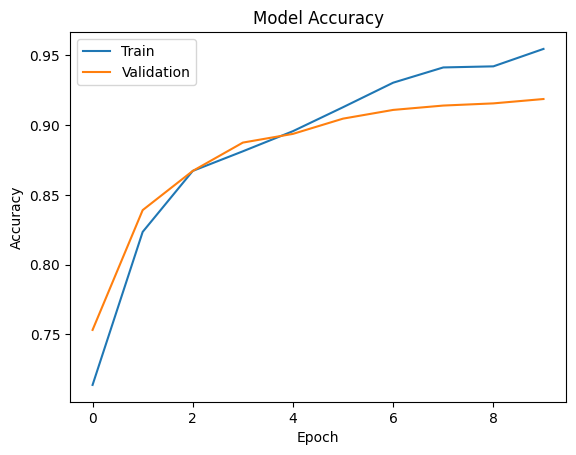

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])

plt.show()

In [28]:
model.save("bird_sound_cnn.keras")

print("Model Saved")

Model Saved


In [31]:
test_file = r"E:\dataset\non_bird\audio\fold10\7913-3-0-0.wav"

spec = audio_to_spec(test_file)

spec = np.expand_dims(spec, axis=0)

prediction = model.predict(spec)

print("Prediction:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Bird Sound Detected")
else:
    print("Non-Bird Sound")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Prediction: 0.013423372
Non-Bird Sound


In [30]:
test_file = r"D:\XC380406 - Night Parrot - Pezoporus occidentalis.mp3"

spec = audio_to_spec(test_file)

spec = np.expand_dims(spec, axis=0)

prediction = model.predict(spec)

print("Prediction:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Bird Sound Detected")
else:
    print("Non-Bird Sound")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Prediction: 0.99138016
Bird Sound Detected


In [32]:
from tensorflow.keras.models import load_model

model = load_model("bird_sound_cnn.keras")

In [33]:
import numpy as np

X = np.load("X.npy")
y = np.load("y.npy")

print(X.shape)
print(y.shape)

(4000, 128, 128, 1)
(4000,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step

Overall Accuracy: 91.38%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       400
           1       0.91      0.92      0.91       400

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800

Confusion Matrix:
[[365  35]
 [ 34 366]]
